In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load
df = pd.read_csv("../data/ecommerce.csv")
print(df.head())

  Customer_ID  Age  Gender       City Device_Type  Session_Duration  \
0      C00001   25    Male       Pune      Laptop                12   
1      C00002   45    Male  Bangalore      Mobile                11   
2      C00003   46  Female    Kolkata      Mobile                29   
3      C00004   31  Female  Bangalore      Mobile                17   
4      C00005   47    Male    Chennai      Mobile                22   

   Pages_Viewed Product_Category  Price  Discount  Purchase_History  \
0             5          Fashion   4016         5                 9   
1             5      Electronics  26390        10                 9   
2            14          Fashion   3859        20                 6   
3             3             Home   4317        25                 5   
4             6             Home   3075        30                 2   

   Time_Spent_on_Product Payment_Method  Cart_Value Purchased  
0                      4     Debit Card        3815        No  
1                 

{'max_depth': None, 'n_estimators': 50}
0.9998750156230471


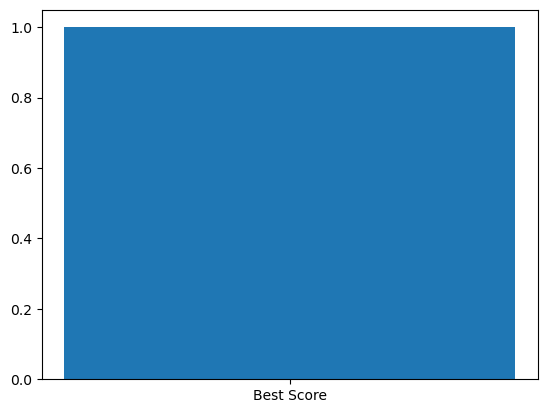

In [5]:
df.columns = df.columns.str.strip().str.lower()
# Convert target
df["purchased"] = df["purchased"].map({"Yes": 1, "No": 0})

# Drop ID column
df = df.drop(columns=["customer_id"], errors="ignore")
# Drop missing values
df = df.dropna()

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)
# Define features and target
y = df["purchased"]
X = df.drop(columns=["purchased"])

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators":[50,100],
    "max_depth":[None,10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

pd.DataFrame([grid.best_params_]).to_csv("rq5_table.csv")

plt.bar(["Best Score"], [grid.best_score_])
plt.savefig("rq5_figure.pdf")
plt.show()